# 02 - ΛCDM limits

accDM must reduce to ΛCDM in two limits:

- **f_acc → 0:** no accDM at all. The deviation from ΛCDM should fall roughly linearly with f_acc.
- **η → 0:** the daughter is born without a kick, so it is cold, and a cold daughter of a cold parent
  is just CDM. It is born at v ≈ √(2η) c, so "cold" needs very small η: η = 10⁻⁴ is still 4000 km/s and
  free-streams like a hot component. P(k) only approaches ΛCDM below η ≈ 10⁻⁸.

a_t has no such limit: the parent always converts fully by a = 1; a_t only sets when.

Model: m = 10¹⁶ GeV, κ = 12.1, a_t = 0.133, strategy-5 daughter grid at 100 bins/decade. The ΛCDM
reference has the same neutrinos (one species, 3 × 0.02 eV). Raw (unlensed) C_ℓ, for speed.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from accdm_nb import accdm_params, lcdm_params, run_class, plot_style

plot_style()

LMAX = 2500
K_NODES = np.logspace(-3, 0.7, 20)          # 1/Mpc
MASS = 1e16
OUTPUT = {'output': 'tCl,pCl,mPk', 'l_max_scalars': LMAX, 'P_k_max_1/Mpc': 10.0, 'z_max_pk': 0.0}
GRID = {'accdm_q_bins_per_decade': 100, 'accdm_q_number_tol': 1e-8}


def spectra(cosmo):
    return {'tt': np.asarray(cosmo.raw_cl(LMAX)['tt'])[2:],
            'pk': np.array([cosmo.pk(k, 0.0) for k in K_NODES]), 'sigma8': cosmo.sigma8()}


def deviation(o, ref):
    """C_l TT relative to max C_l, P(k) element-wise, sigma8."""
    return {'TT': float(np.max(np.abs(o['tt'] - ref['tt']))/np.max(ref['tt'])),
            'P(k)': float(np.max(np.abs(o['pk']/ref['pk'] - 1))),
            'sigma8': abs(o['sigma8']/ref['sigma8'] - 1)}


runs = {}
def accdm(f_acc, eta):
    if (f_acc, eta) not in runs:
        runs[(f_acc, eta)] = run_class(accdm_params(f_acc, MASS, eta=eta, **OUTPUT, **GRID), spectra)
        assert 'error' not in runs[(f_acc, eta)], runs[(f_acc, eta)]['error']
    return runs[(f_acc, eta)]


ref = run_class(lcdm_params(**OUTPUT), spectra)
assert 'error' not in ref, ref['error']
print('ΛCDM: sigma8 = {:.5f}'.format(ref['sigma8']))

ΛCDM: sigma8 = 0.81307


## A. f_acc → 0 at η = 0.1

In [2]:
F_SEQ = [1e-1, 1e-2, 1e-3]
TOL_A = 1e-2                 # allowed deviation at the smallest f_acc
dev_f = [deviation(accdm(f, 0.1), ref) for f in F_SEQ]

print('{:>8} {:>10} {:>10} {:>10} {:>12}'.format('f_acc', 'TT', 'P(k)', 'sigma8', 'TT / f_acc'))
for f, d in zip(F_SEQ, dev_f):
    print('{:>8.0e} {:>10.2e} {:>10.2e} {:>10.2e} {:>12.2e}'.format(f, d['TT'], d['P(k)'], d['sigma8'], d['TT']/f))

tt = [d['TT'] for d in dev_f]
assert tt[0] > tt[1] > tt[2], 'deviation does not fall as f_acc -> 0'
assert max(dev_f[-1].values()) < TOL_A, 'no reduction to ΛCDM at f_acc = {:g}'.format(F_SEQ[-1])
print('\nA passed')

   f_acc         TT       P(k)     sigma8   TT / f_acc


   1e-01   6.88e-03   2.64e-01   1.41e-01     6.88e-02
   1e-02   6.30e-04   3.21e-02   1.61e-02     6.30e-02
   1e-03   6.10e-05   3.28e-03   1.63e-03     6.10e-02

A passed


## B. η → 0 at f_acc = 0.01

P(k) and σ8 must fall monotonically (until σ8 reaches its ~3·10⁻⁸ floor) and be below 10⁻⁴ at η = 10⁻¹². C_ℓ^TT is not asserted: it sits at a
~3·10⁻⁵ floor already at η = 10⁻², since the CMB barely sees a 1% component that becomes warm after
recombination.

In [3]:
E_SEQ = [1e-2, 1e-4, 1e-6, 1e-8, 1e-10, 1e-12]
F_B = 0.01
TOL_B = 1e-4
dev_e = [deviation(accdm(F_B, e), ref) for e in E_SEQ]

print('{:>8} {:>12} {:>10} {:>10} {:>10}'.format('eta', 'v [km/s]', 'TT', 'P(k)', 'sigma8'))
for e, d in zip(E_SEQ, dev_e):
    v = 299792*np.sqrt(e*(e + 2))/(1 + e)
    print('{:>8.0e} {:>12.3g} {:>10.2e} {:>10.2e} {:>10.2e}'.format(e, v, d['TT'], d['P(k)'], d['sigma8']))

FLOOR = 1e-6             # sigma8 reaches its numerical floor (~3e-8) by eta = 1e-10
for key in ('P(k)', 'sigma8'):
    dev = [d[key] for d in dev_e]
    assert all(b < a or b < FLOOR for a, b in zip(dev, dev[1:])), '{} deviation does not fall as eta -> 0'.format(key)
assert dev_e[-1]['P(k)'] < TOL_B and dev_e[-1]['sigma8'] < TOL_B, 'no reduction to ΛCDM at eta = {:g}'.format(E_SEQ[-1])
print('\nB passed')

     eta     v [km/s]         TT       P(k)     sigma8
   1e-02     4.21e+04   7.70e-05   3.06e-02   1.50e-02
   1e-04     4.24e+03   2.64e-05   3.04e-02   9.87e-03
   1e-06          424   2.63e-05   2.92e-02   4.89e-04
   1e-08         42.4   2.61e-05   9.47e-03   5.36e-06
   1e-10         4.24   2.46e-05   1.17e-04   2.63e-08
   1e-12        0.424   2.64e-05   1.11e-06   3.05e-08

B passed


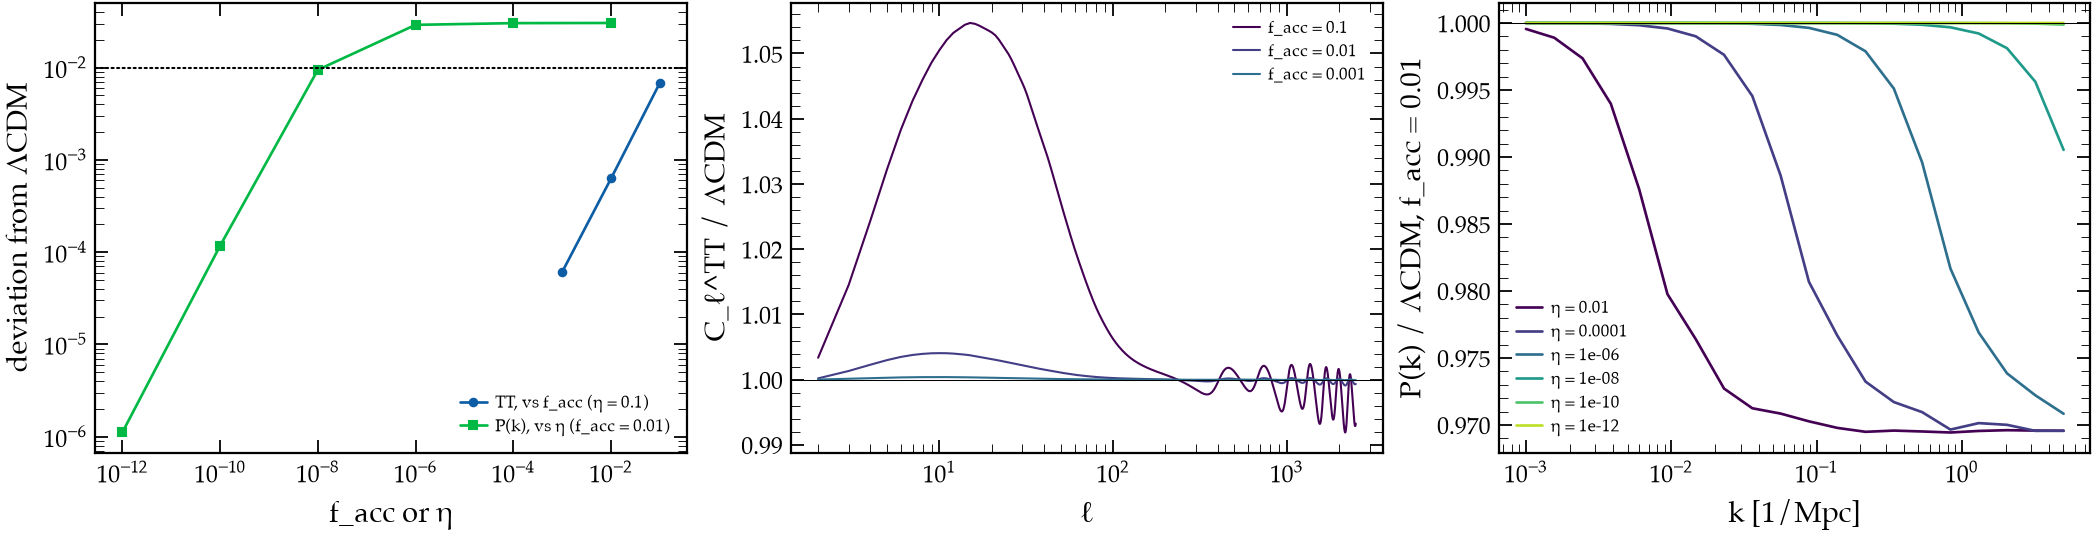

In [4]:
colors = plt.cm.viridis(np.linspace(0, 0.9, len(E_SEQ)))
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), constrained_layout=True)
axes[0].loglog(F_SEQ, [d['TT'] for d in dev_f], 'o-', label='TT, vs f_acc (η = 0.1)')
axes[0].loglog(E_SEQ, [d['P(k)'] for d in dev_e], 's-', label='P(k), vs η (f_acc = {:g})'.format(F_B))
axes[0].axhline(TOL_A, color='k', ls=':', lw=1)
axes[0].set_xlabel('f_acc or η')
axes[0].set_ylabel('deviation from ΛCDM')
axes[0].legend(fontsize=8)
for f, c in zip(F_SEQ, colors):
    axes[1].plot(np.arange(2, LMAX + 1), accdm(f, 0.1)['tt']/ref['tt'], color=c, lw=1, label='f_acc = {:g}'.format(f))
axes[1].set_xscale('log')
axes[1].set_xlabel('ℓ')
axes[1].set_ylabel('C_ℓ^TT / ΛCDM')
axes[1].legend(fontsize=8)
for e, c in zip(E_SEQ, colors):
    axes[2].semilogx(K_NODES, accdm(F_B, e)['pk']/ref['pk'], color=c, label='η = {:g}'.format(e))
axes[2].set_xlabel('k [1/Mpc]')
axes[2].set_ylabel('P(k) / ΛCDM, f_acc = {:g}'.format(F_B))
axes[2].legend(fontsize=8)
for ax in axes[1:]:
    ax.axhline(1, color='k', lw=0.5)
plt.show()